In [22]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [23]:
df = pd.read_parquet("sp500_1d_tech_indicators.parquet", engine="pyarrow")

df.iloc[100:200]

Feature,Close,High,Low,Open,Volume,Target,MA5,MA10,MA20,MA50,...,Vol_MA10,Vol_MA20,Vol_MA10_Ratio,Vol_MA20_Ratio,Vol_Spike,Vol_Z,MFI,ZClose20,Stoch_K%,Stoch_D%
Ticker,MMM,MMM,MMM,MMM,MMM,MMM,MMM,MMM,MMM,MMM,...,ZTS,ZTS,ZTS,ZTS,ZTS,ZTS,ZTS,ZTS,ZTS,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2005-12-02,37.399776,37.559925,37.183100,37.234917,2074342,0,37.088884,36.975162,36.470107,35.207518,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-12-05,36.891060,37.583477,36.806277,37.258464,3422713,0,37.100191,37.002215,36.554617,35.265498,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-12-06,36.599018,37.070048,36.514235,36.952291,4124526,0,37.038959,36.949931,36.607656,35.312202,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-12-07,36.448284,37.164250,36.316395,36.928735,4569916,0,36.935334,36.907540,36.650817,35.355423,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-12-08,36.241009,36.735592,36.198617,36.660226,2687412,0,36.715829,36.851485,36.680334,35.399184,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-04-21,40.319149,40.527715,39.774038,39.816702,11084767,0,39.000468,38.691415,37.627977,35.917300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-24,40.508778,40.717339,39.816726,39.821467,5218985,0,39.493438,38.901401,37.833224,36.048062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
FEATURES = [
  'ROC10', 'Stoch_K%', 'DC_Breakout_Strength', 'ROC20',
  'ROC5', 'Vol_MA20', 'ROC50', 'Stoch_D%', 'ZClose20', 'MFI', 'RSI14',
  'SD10', 'MACD', 'MACD_Histo', 'Vol_Z', 'SD50', 'MACD_Signal', 'Vol_MA20_Ratio',
  'SD5', 'DC_Mid', 'MA5', 'ATR14', 'BollBandwidth', 'DC_Width'
]

In [42]:
results = {}

apple = df.xs('AAPL', axis=1, level='Ticker').copy()
apple.sort_index(inplace=True)

apple.dropna(inplace=True)

results = []
window_size = 2000
test_size = 200
step_size = 100

for start in range(0, len(apple) - window_size - test_size, step_size):
  train = apple.iloc[start:start+window_size]
  test = apple.iloc[start+window_size : start+window_size+test_size]

  X_train = train[FEATURES]
  y_train = train["Target"]
  X_test = test[FEATURES]
  y_test = test["Target"]

  clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42
  )
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
    
  results.append(acc)

np.mean(results)

np.float64(0.5985714285714286)

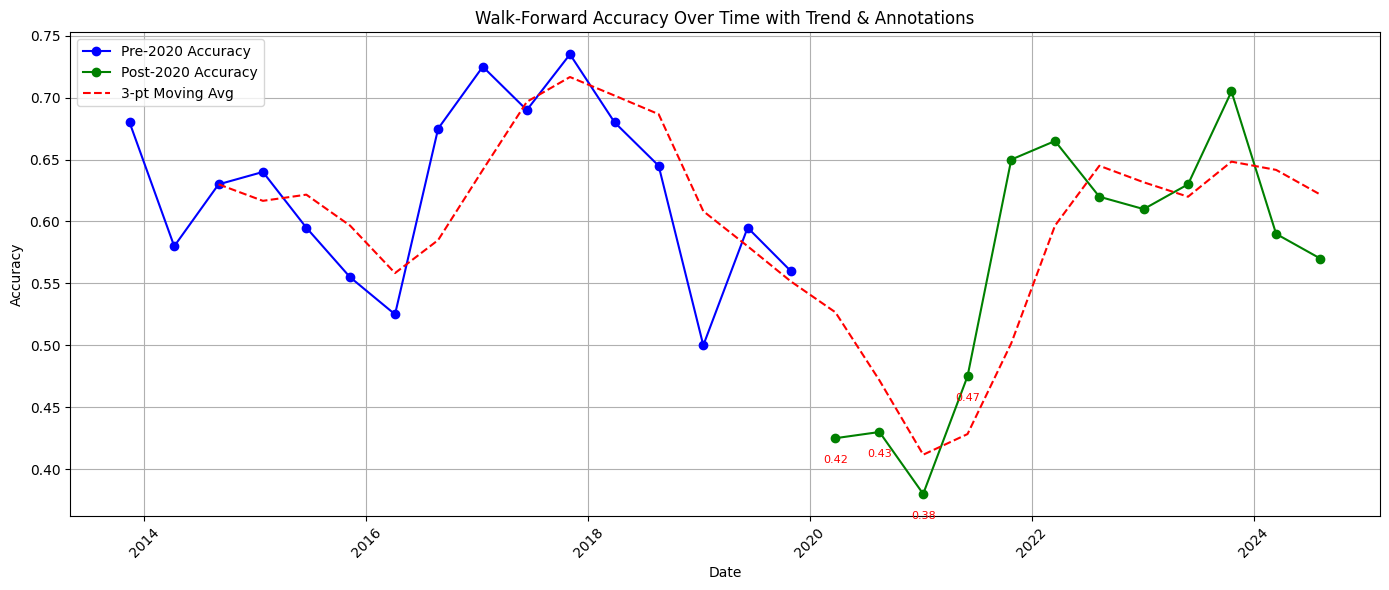

In [44]:
midpoints = [
  apple.index[start + window_size + test_size // 2]
  for start in range(0, len(apple) - window_size - test_size, step_size)
]

results_series = pd.Series(results, index=midpoints)
rolling_avg = results_series.rolling(window=3).mean()

plt.figure(figsize=(14, 6))

pre_2020 = results_series[results_series.index < pd.Timestamp("2020-01-01")]
post_2020 = results_series[results_series.index >= pd.Timestamp("2020-01-01")]

plt.plot(pre_2020.index, pre_2020.values, marker='o', label='Pre-2020 Accuracy', color='blue')
plt.plot(post_2020.index, post_2020.values, marker='o', label='Post-2020 Accuracy', color='green')

plt.plot(rolling_avg.index, rolling_avg.values, linestyle='--', color='red', label='3-pt Moving Avg')

for date, acc in results_series.items():
  if acc < 0.5:
    plt.text(date, acc - 0.02, f"{acc:.2f}", color='red', fontsize=8, ha='center')

plt.title("Walk-Forward Accuracy Over Time with Trend & Annotations")
plt.xlabel("Date")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


In [46]:
X = apple[FEATURES]
y = apple["Target"]

clf = XGBClassifier(
  n_estimators=300,
  learning_rate=0.05,
  max_depth=4,
  subsample=0.8,
  colsample_bytree=0.8,
  tree_method="hist",
  use_label_encoder=False,
  eval_metric="logloss",
  random_state=42
)

clf.fit(X, y)

/home/eric/repos/stock-predictor/.venv/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [20:07:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [48]:
latest_data = apple[FEATURES].iloc[-1:]

clf.predict(latest_data)

array([0])